In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [2]:
DATASET_PATH = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

Found 1811 files belonging to 7 classes.
Found 362 files belonging to 7 classes.
Found 365 files belonging to 7 classes.


In [5]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [6]:
inputs = tf.keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(7, activation="softmax")(x)

resnet_model = Model(inputs, outputs)

In [7]:
resnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "resnet50_best.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [10]:
history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.4169 - loss: 1.6164 - val_accuracy: 0.7348 - val_loss: 0.7900 - learning_rate: 1.0000e-04
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6527 - loss: 0.9101 - val_accuracy: 0.7956 - val_loss: 0.5913 - learning_rate: 1.0000e-04
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.7289 - loss: 0.7325 - val_accuracy: 0.8232 - val_loss: 0.5062 - learning_rate: 1.0000e-04
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.7830 - loss: 0.6067 - val_accuracy: 0.8425 - val_loss: 0.4429 - learning_rate: 1.0000e-04
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8117 - loss: 0.5209 - val_accuracy: 0.8619 - val_loss: 0.3913 - learning_rate: 1.0000e-04
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.8244 - loss: 0.4737 - val_accuracy: 0.8619 - val_loss: 0.3711 - learning_rate: 1.0000e-04
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8437 

In [11]:
test_loss, test_accuracy = resnet_model.evaluate(test_ds)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9479 - loss: 0.1707
Test Loss     : 0.1707
Test Accuracy : 0.9479


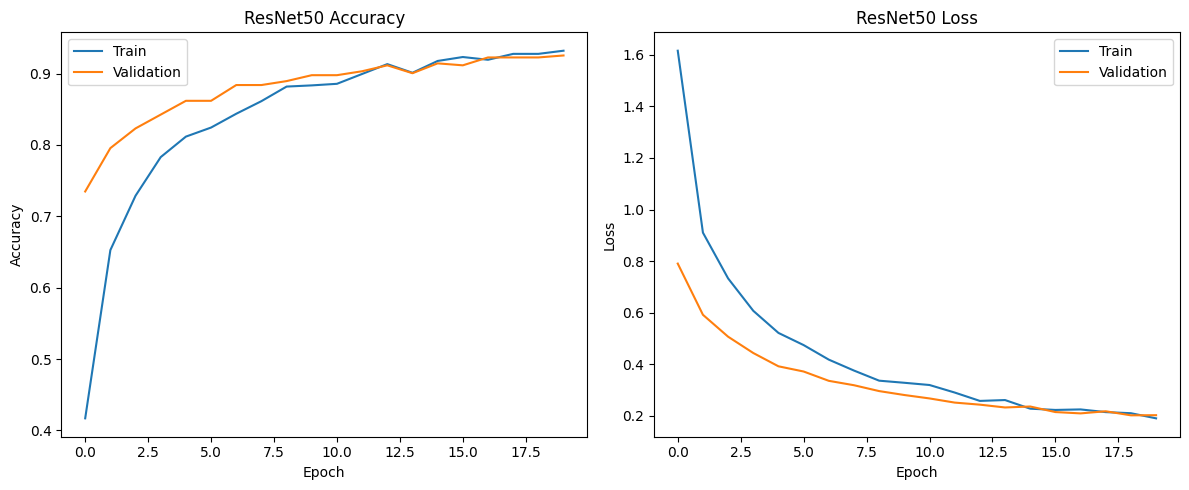

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds])

predictions = resnet_model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      0.98      0.99        55
           brown_spot       0.89      0.85      0.87        59
              healthy       0.96      0.97      0.96        66
           leaf_blast       0.94      0.94      0.94        63
           leaf_scald       1.00      0.96      0.98        54
            leaf_smut       1.00      0.83      0.91         6
    narrow_brown_spot       0.91      1.00      0.95        62

             accuracy                           0.95       365
            macro avg       0.96      0.93      0.94       365
         weighted avg       0.95      0.95      0.95       365



<Figure size 800x800 with 0 Axes>

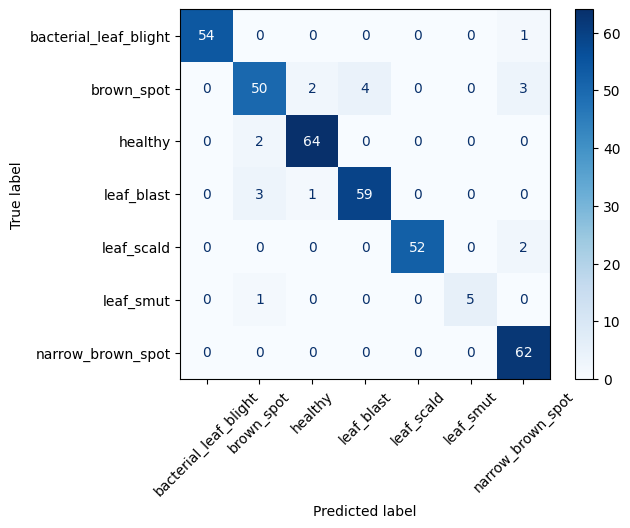

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

In [15]:
resnet_model.save("resnet50_final.keras")
print("Model saved successfully!")

Model saved successfully!


NameError: name 'efficientnet_model' is not defined